# Business Question:-
Can we predict whether an employee is likely to leave the organization based on factors such as age, income, job satisfaction, overtime, job level, etc.?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [5]:
df= pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
#No null values
#data in both int as well as object


In [7]:
df.shape

(1470, 35)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
#our target here is attrition so let's visualize attrition

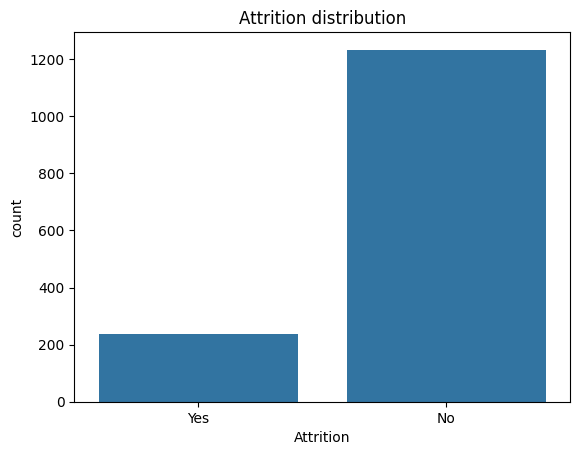

In [11]:
sns.countplot(x= 'Attrition', data= df)
plt.title('Attrition distribution')
plt.show()

In [12]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
#237 employees have left the organization
#this data has close to 80% No's so we have a class imbalancing issue here and this accuracy could be misleading here.

Let us now analyse the data step by step with respect to attrition

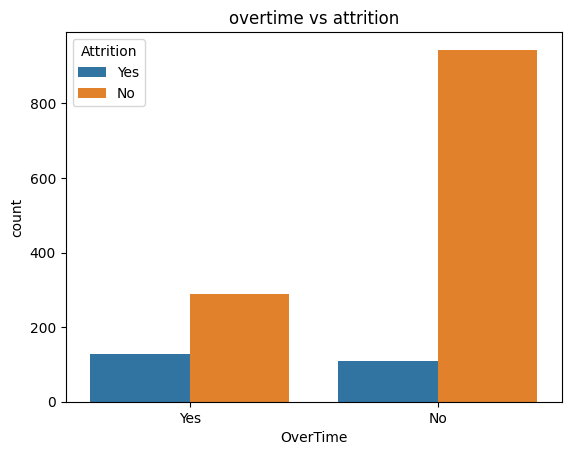

In [14]:
#Does overtime relate to attrition
sns.countplot(x= 'OverTime', hue= 'Attrition', data= df)
plt.title('overtime vs attrition')
plt.show()

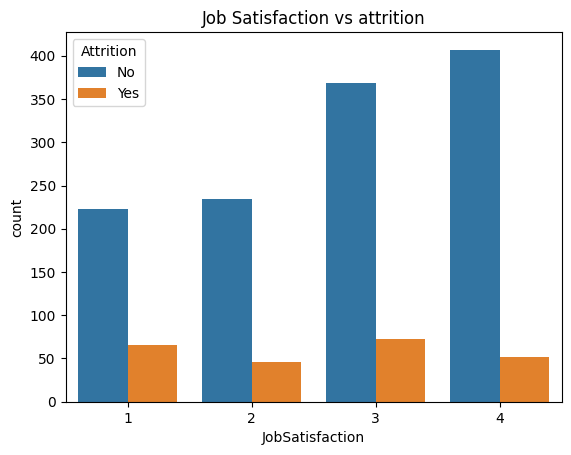

In [15]:
#Does job satisfaction relate to attrition?
sns.countplot(x= 'JobSatisfaction', hue= 'Attrition', data= df)
plt.title('Job Satisfaction vs attrition')
plt.show()


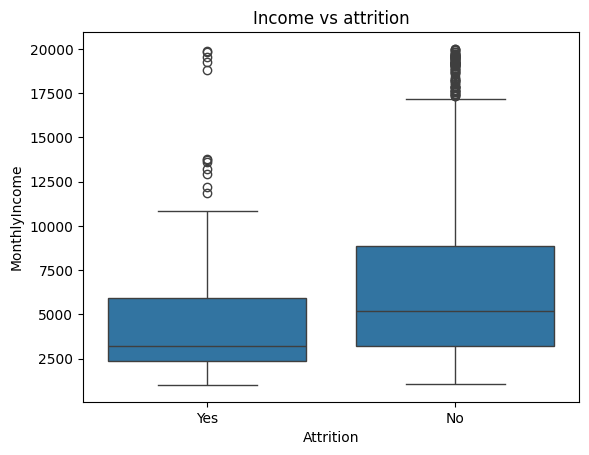

In [23]:
#Does income relate to attrition?
sns.boxplot(x= 'Attrition', y= 'MonthlyIncome', data= df)
plt.title('Income vs attrition')
plt.show()

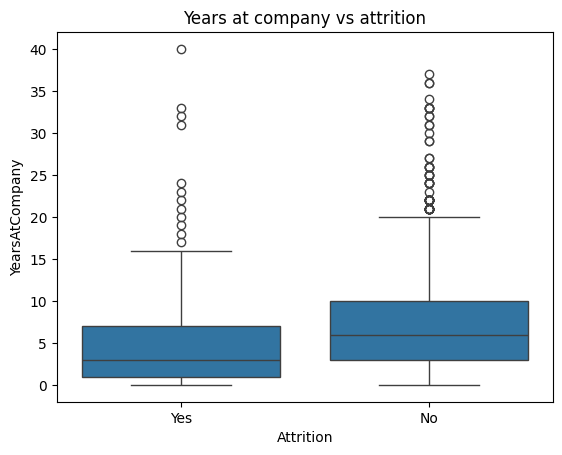

In [24]:
#years at the company

sns.boxplot(x= 'Attrition', y= 'YearsAtCompany', data= df)
plt.title('Years at company vs attrition')
plt.show()

Insights:-

1. High attrition in employees who did overtime.
2. Lower job satisfaction also plays a role in the employee leaving the organization however we can see that we have lot of attrition with people having job satisfaction of 4.
3. People with lower median monthly income have higher chance of attrition however we have some outliers here.
4. Less experience also results in higher attrition.



In [27]:
#Remove columns which are not required as they are not relevant for our analysis
df= df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)



KeyError: "['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'] not found in axis"

In [28]:
df.shape

(1470, 31)

In [29]:
#Now let us now convert categorical data into numerical data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [31]:
#Attrition
from sklearn.preprocessing import LabelEncoder
Le= LabelEncoder()
df['Attrition']= Le.fit_transform(df['Attrition'])

In [32]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [33]:
#One-hot encoding
df= pd.get_dummies(df,drop_first=True)


In [34]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [36]:
#model building

In [45]:
#dependent and independent variable
x= df.drop('Attrition', axis=1)
y= df['Attrition']
x

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,True,False,False,False,False,False,False,True,False,False
1466,39,613,6,1,4,42,2,3,1,9991,...,False,False,False,False,False,False,False,True,False,False
1467,27,155,4,3,2,87,4,2,2,6142,...,False,False,True,False,False,False,False,True,False,True
1468,49,1023,2,3,4,63,2,2,2,5390,...,False,False,False,False,False,True,False,True,False,False


In [47]:
y

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


In [50]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [53]:
from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier()

In [54]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [55]:
y_pred= model.predict(x_test)

In [56]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0])

In [60]:
#Let's evaluate the model

from sklearn.metrics import *

In [64]:
print('accuracy scores:', accuracy_score(y_test,y_pred))
print('precision scores:', precision_score(y_test,y_pred))
print('recall scores:', recall_score(y_test,y_pred))
print('f1 scores:', f1_score(y_test,y_pred))

accuracy scores: 0.7857142857142857
precision scores: 0.34
recall scores: 0.3617021276595745
f1 scores: 0.35051546391752575


In [66]:
#confusion matrix
cm= confusion_matrix(y_test,y_pred)
cm

array([[214,  33],
       [ 30,  17]])

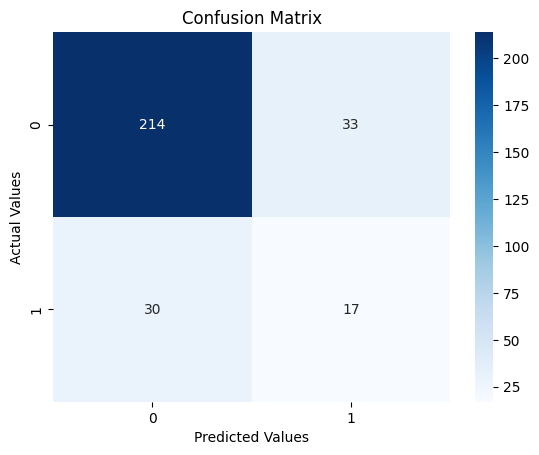

In [67]:
sns.heatmap(cm, annot=True, fmt= 'd', cmap= 'Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')
plt.show()

Insights:-
1. Model unable to predict 30 employees employees who left.
2. 33 employees stayed but model predicted them to leave thus results in wasting resources on retaining them.

In [69]:
train_pred = model.predict(x_train)

print("Training Accuracy:",
      accuracy_score(y_train, train_pred))

print("Testing Accuracy:",
      accuracy_score(y_test, y_pred))

Training Accuracy: 1.0
Testing Accuracy: 0.7857142857142857


In [70]:
#classification report.
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87       247
           1       0.34      0.36      0.35        47

    accuracy                           0.79       294
   macro avg       0.61      0.61      0.61       294
weighted avg       0.79      0.79      0.79       294



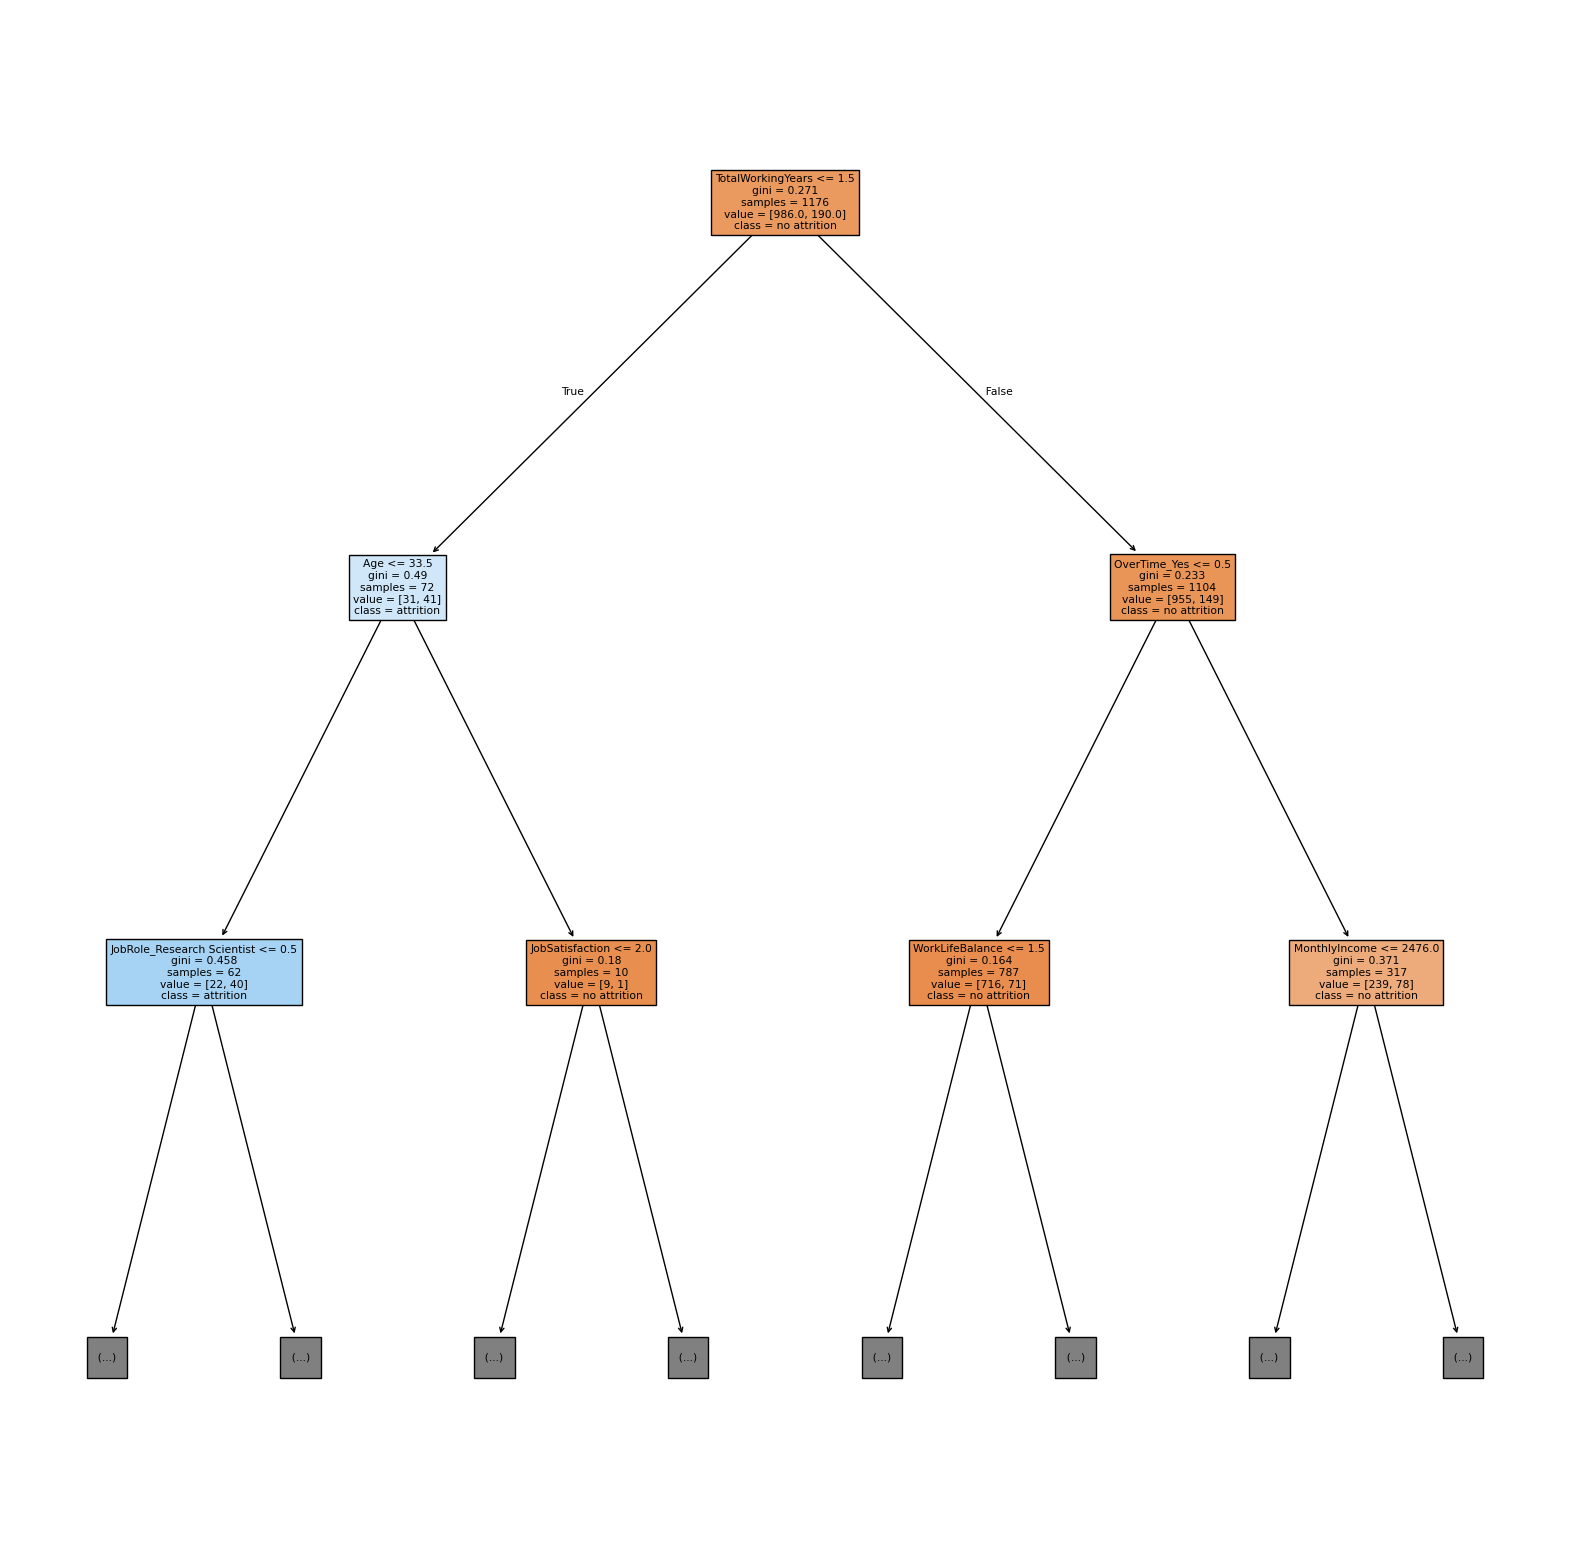

In [75]:
#let's visualize the decision tree

from sklearn.tree import plot_tree

plt.figure(figsize= (20,20))
plot_tree(model, feature_names= x.columns, filled= True, class_names= ['no attrition', 'attrition'], max_depth=2)
plt.show()

In [78]:
#Now let's focus on model improvement
model_1= DecisionTreeClassifier(criterion= 'gini', max_depth= 5, random_state= 42)
model_1.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [79]:
y_pred1= model_1.predict(x_test)

In [81]:
print('accuracy scores:', accuracy_score(y_test,y_pred1))
print('precision scores:', precision_score(y_test,y_pred1))
print('recall scores:', recall_score(y_test,y_pred1))
print('f1 scores:', f1_score(y_test,y_pred1))

accuracy scores: 0.8333333333333334
precision scores: 0.4444444444444444
recall scores: 0.1702127659574468
f1 scores: 0.24615384615384617


In [84]:
model_2 = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=10, random_state=42)
model_2.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

In [85]:
y_pred2= model_2.predict(x_test)

In [86]:
print('accuracy scores:', accuracy_score(y_test,y_pred2))
print('precision scores:', precision_score(y_test,y_pred2))
print('recall scores:', recall_score(y_test,y_pred2))
print('f1 scores:', f1_score(y_test,y_pred2))

accuracy scores: 0.8435374149659864
precision scores: 0.5263157894736842
recall scores: 0.2127659574468085
f1 scores: 0.30303030303030304


In [87]:
#Balanced model:- because there is high class imbalance

model_3= DecisionTreeClassifier(criterion= 'gini', max_depth=5, min_samples_leaf=10, class_weight= 'balanced', random_state=42)
model_3.fit(x_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, random_state=42)

In [88]:
y_pred3= model_3.predict(x_test)

In [89]:
print('accuracy scores:', accuracy_score(y_test,y_pred3))
print('precision scores:', precision_score(y_test,y_pred3))
print('recall scores:', recall_score(y_test,y_pred3))
print('f1 scores:', f1_score(y_test,y_pred3))

accuracy scores: 0.7687074829931972
precision scores: 0.3561643835616438
recall scores: 0.5531914893617021
f1 scores: 0.43333333333333335


In [90]:
print('confusion matrix:', confusion_matrix(y_test,y_pred3))

confusion matrix: [[200  47]
 [ 21  26]]


In [93]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.90      0.81      0.85       247
           1       0.36      0.55      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.68      0.64       294
weighted avg       0.82      0.77      0.79       294



The model demonstrates moderate ability to identify employees at risk of attrition, with recall of 55.3%, but precision remains relatively low at 35.6%. Further tuning or more advanced models could potentially improve performance.

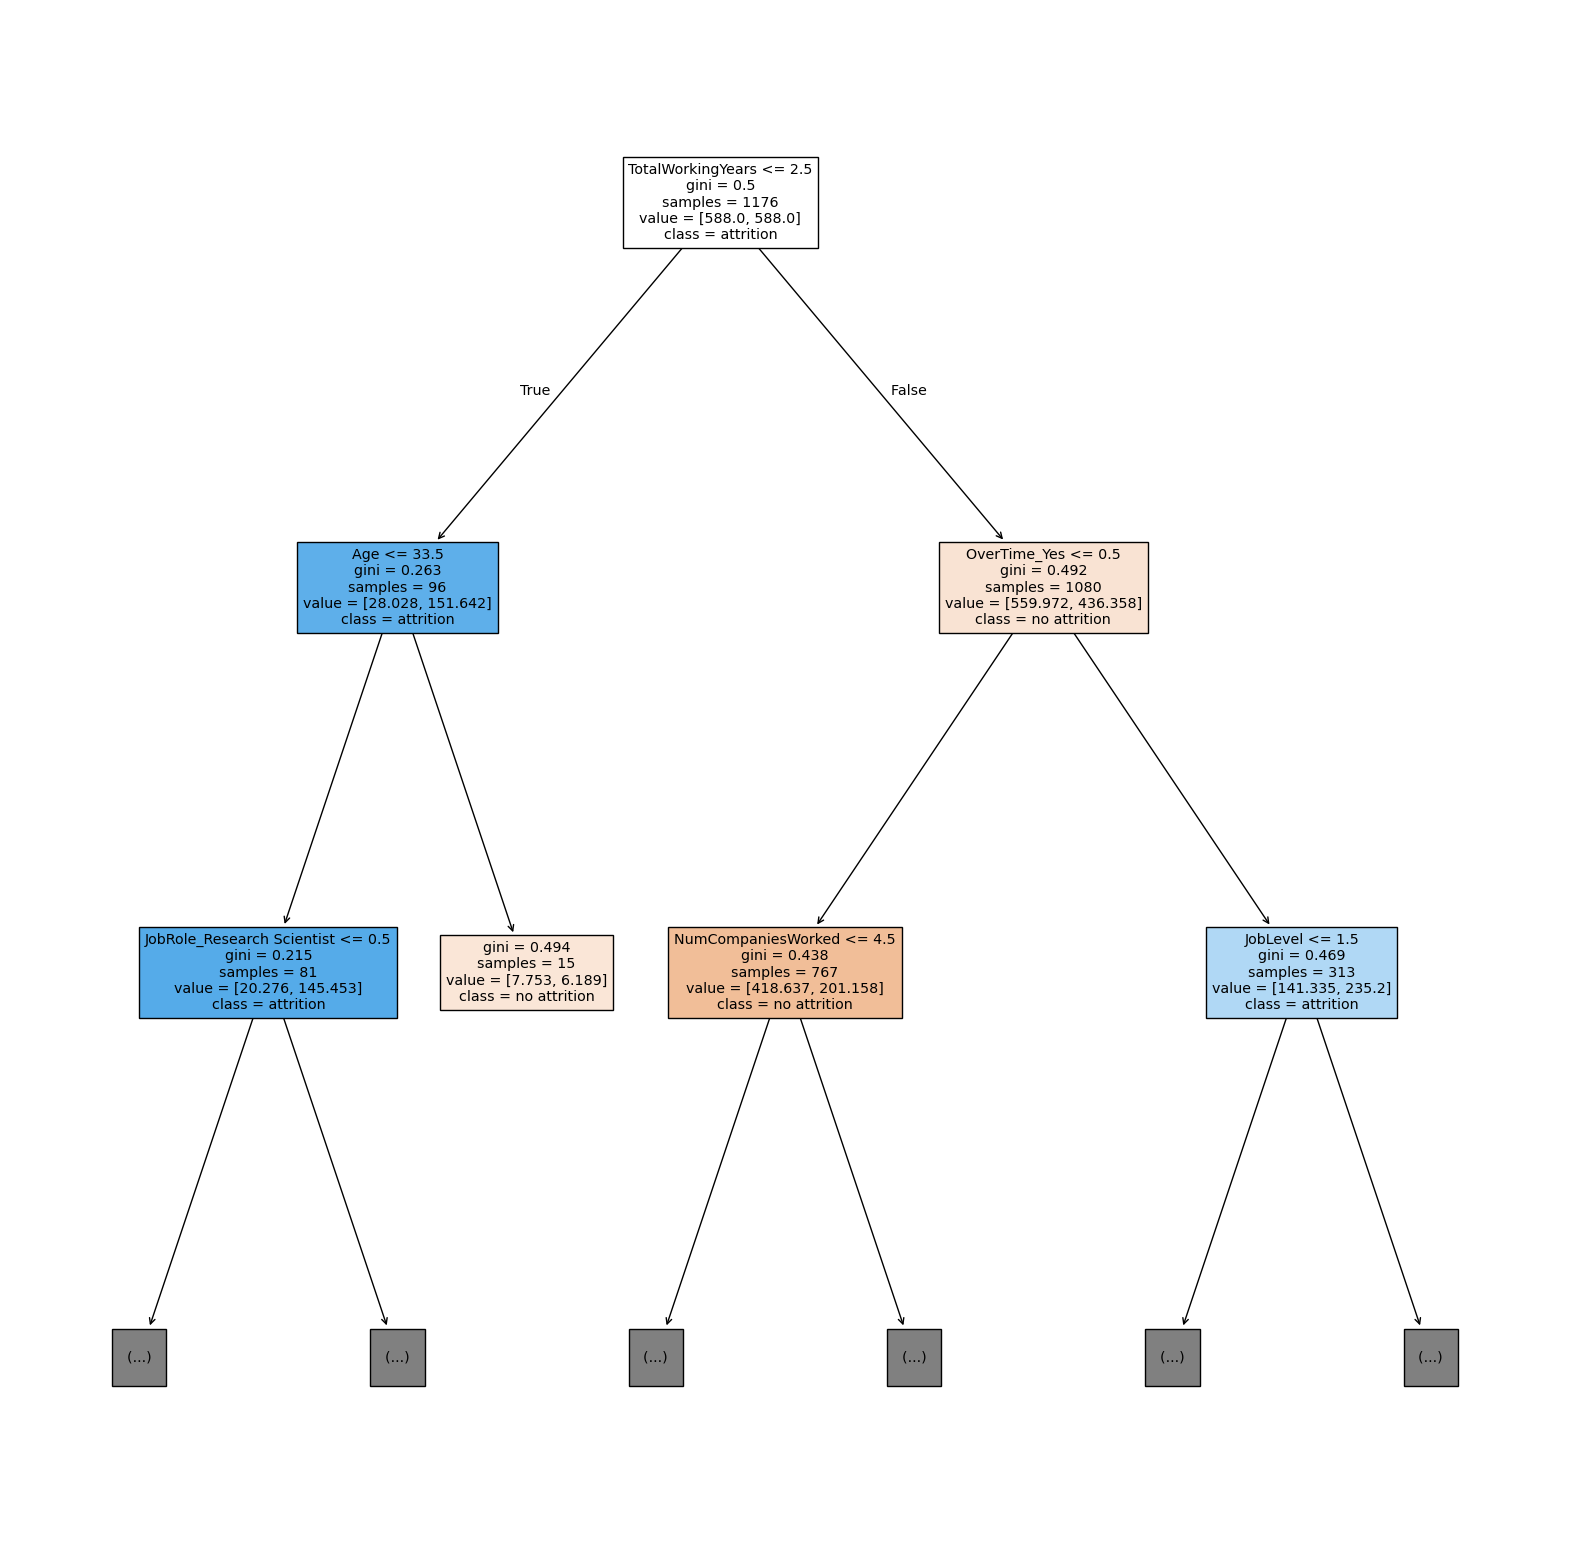

In [102]:
from sklearn.tree import plot_tree

plt.figure(figsize= (20,20))
plot_tree(model_3, feature_names= x.columns, filled= True, class_names= ['no attrition', 'attrition'], max_depth=2)
plt.show()

In [95]:
train_pred= model_3.predict(x_train)

print("Training Accuracy:",
      accuracy_score(y_train, train_pred ))

print("Testing Accuracy:",
      accuracy_score(y_test, y_pred3))

Training Accuracy: 0.8460884353741497
Testing Accuracy: 0.7687074829931972


In [96]:
#model comparison

model_results = {
    "Baseline Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    },

    "Model 2": {
        "Accuracy": accuracy_score(y_test, y_pred2),
        "Precision": precision_score(y_test, y_pred2),
        "Recall": recall_score(y_test, y_pred2),
        "F1 Score": f1_score(y_test, y_pred2)
    },

    "Balanced Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred3),
        "Precision": precision_score(y_test, y_pred3),
        "Recall": recall_score(y_test, y_pred3),
        "F1 Score": f1_score(y_test, y_pred3)
    }
}

In [99]:
comparison_df= pd.DataFrame(model_results).T
print(comparison_df)

                        Accuracy  Precision    Recall  F1 Score
Baseline Decision Tree  0.785714   0.340000  0.361702  0.350515
Model 2                 0.843537   0.526316  0.212766  0.303030
Balanced Decision Tree  0.768707   0.356164  0.553191  0.433333


Choosing the model?
1. Model 2 gives highest accuracy and precision but poor recall and F1:- which means that the model is conservative.
2. Baseline model is balanced but still poor recall.
3. Balanced model is the best choice because we wish to reduce the attrition and with 55%+ recall we are able to predict 1 out of 2 employees who will leave the organization.